In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

print("✓ All required libraries imported successfully!")


✓ All required libraries imported successfully!


In [2]:
wine_data = pd.read_csv('wine.csv')

print("=== TASK 1: EXPLORATORY DATA ANALYSIS (EDA) ===")
print("\n1. Basic Dataset Information:")
print(f"Dataset shape: {wine_data.shape}")
print(f"Number of samples: {wine_data.shape[0]}")
print(f"Number of features: {wine_data.shape[1]}")

print("\n2. First 5 rows of the dataset:")
print(wine_data.head())

print("\n3. Dataset Info:")
print(wine_data.info())

print("\n4. Statistical Summary:")
print(wine_data.describe())


=== TASK 1: EXPLORATORY DATA ANALYSIS (EDA) ===

1. Basic Dataset Information:
Dataset shape: (178, 14)
Number of samples: 178
Number of features: 14

2. First 5 rows of the dataset:
   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.

In [3]:
print("5. Missing Values Check:")
print(wine_data.isnull().sum())
print(f"\nTotal missing values: {wine_data.isnull().sum().sum()}")

print("\n6. Wine Types Distribution:")
wine_types = wine_data['Type'].value_counts().sort_index()
print("Wine type counts:")
print(wine_types)

print("\nWine type percentages:")
wine_type_percentages = wine_data['Type'].value_counts(normalize=True).sort_index() * 100
for wine_type, percentage in wine_type_percentages.items():
    print(f"Type {wine_type}: {percentage:.1f}%")

X = wine_data.drop('Type', axis=1)
y = wine_data['Type']

print(f"\n7. Feature Matrix Shape: {X.shape}")
print(f"Target Vector Shape: {y.shape}")
print(f"Feature names: {list(X.columns)}")


5. Missing Values Check:
Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

Total missing values: 0

6. Wine Types Distribution:
Wine type counts:
Type
1    59
2    71
3    48
Name: count, dtype: int64

Wine type percentages:
Type 1: 33.1%
Type 2: 39.9%
Type 3: 27.0%

7. Feature Matrix Shape: (178, 13)
Target Vector Shape: (178,)
Feature names: ['Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols', 'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue', 'Dilution', 'Proline']


IndexError: list index out of range

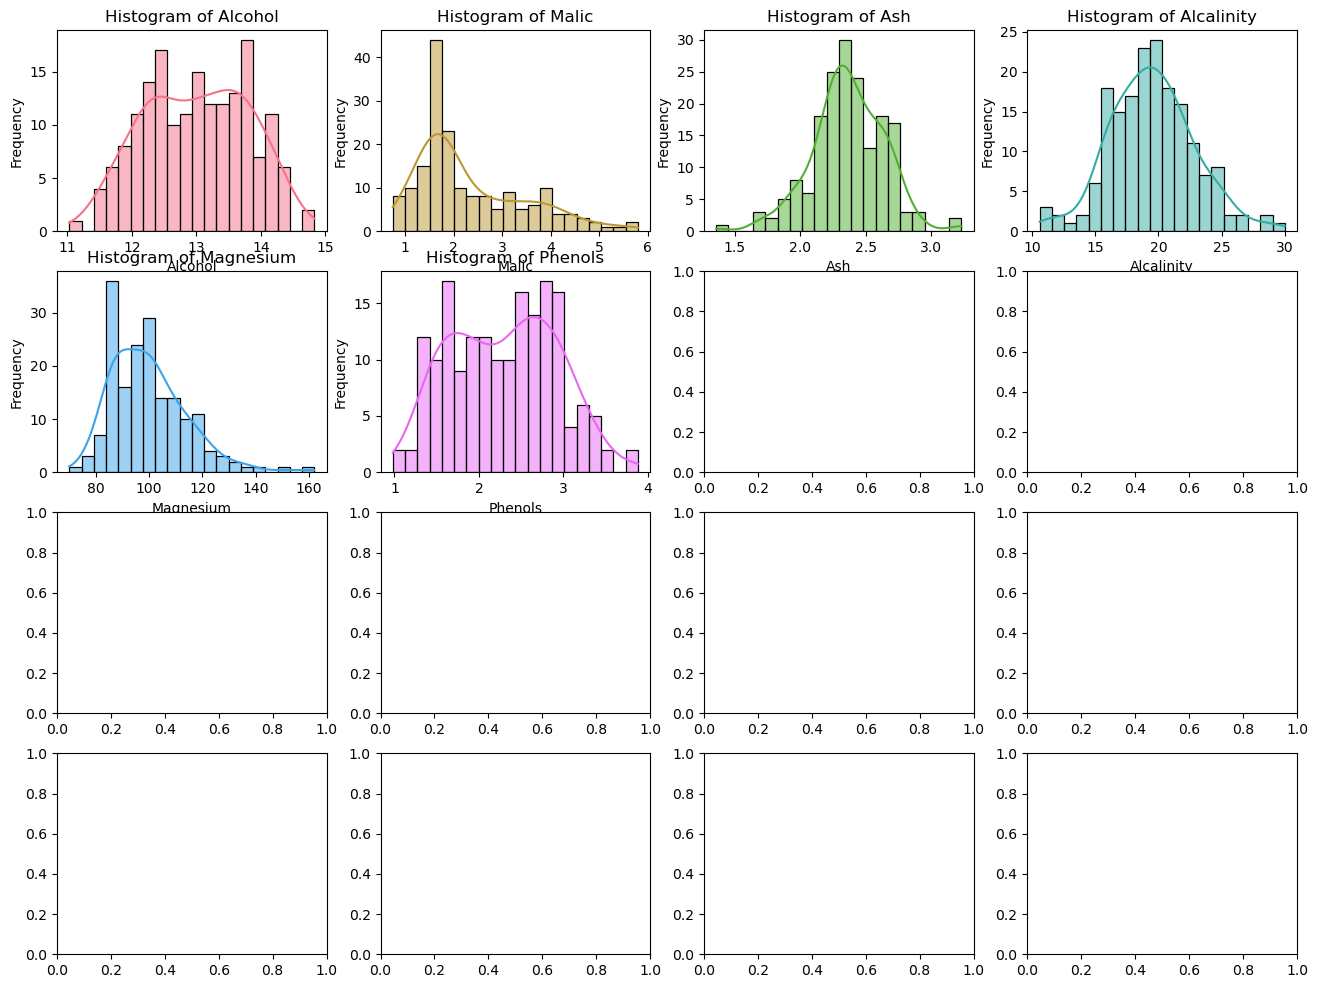

In [18]:
# Cell 4: Robust histogram grid for all features (no index error)
X = wine_data.drop('Type', axis=1)
n_features = len(X.columns)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.histplot(X[col], kde=True, bins=20, ax=axes[i], color=sns.color_palette("husl")[i % 9])
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Feature Distribution - Histograms')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


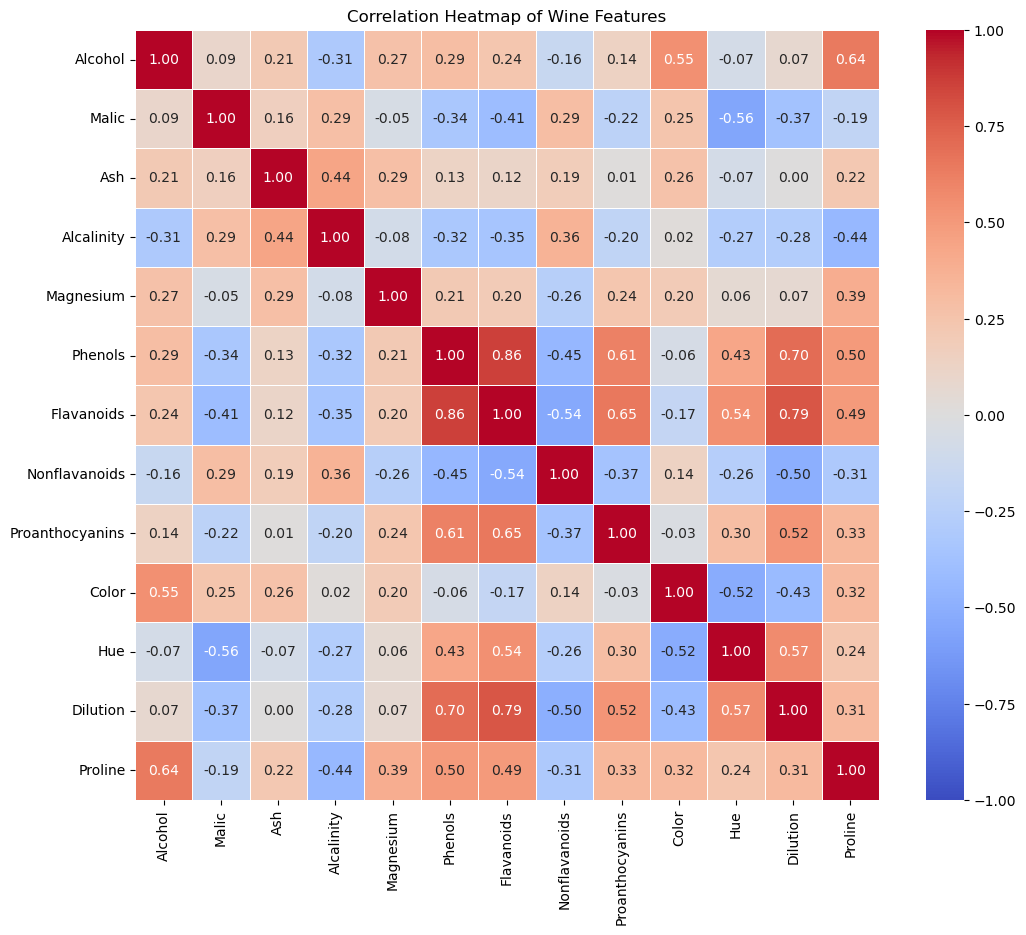

In [7]:
plt.figure(figsize=(12, 10))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Wine Features')
plt.show()


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("=== TASK 2: DIMENSIONALITY REDUCTION WITH PCA ===")
print("Features standardized for PCA (mean ~0, std ~1)")
print(f"Standardized shape: {X_scaled.shape}")
print(f"First row (standardized): {X_scaled[0]}")


=== TASK 2: DIMENSIONALITY REDUCTION WITH PCA ===
Features standardized for PCA (mean ~0, std ~1)
Standardized shape: (178, 13)
First row (standardized): [ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
  1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
  1.01300893]


In [9]:
pca = PCA()
pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("PCA Explained Variance Ratio for Each Component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f}")

print("\nCumulative Explained Variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"Up to PC{i+1}: {cum_var:.4f}")


PCA Explained Variance Ratio for Each Component:
PC1: 0.3620
PC2: 0.1921
PC3: 0.1112
PC4: 0.0707
PC5: 0.0656
PC6: 0.0494
PC7: 0.0424
PC8: 0.0268
PC9: 0.0222
PC10: 0.0193
PC11: 0.0174
PC12: 0.0130
PC13: 0.0080

Cumulative Explained Variance:
Up to PC1: 0.3620
Up to PC2: 0.5541
Up to PC3: 0.6653
Up to PC4: 0.7360
Up to PC5: 0.8016
Up to PC6: 0.8510
Up to PC7: 0.8934
Up to PC8: 0.9202
Up to PC9: 0.9424
Up to PC10: 0.9617
Up to PC11: 0.9791
Up to PC12: 0.9920
Up to PC13: 1.0000


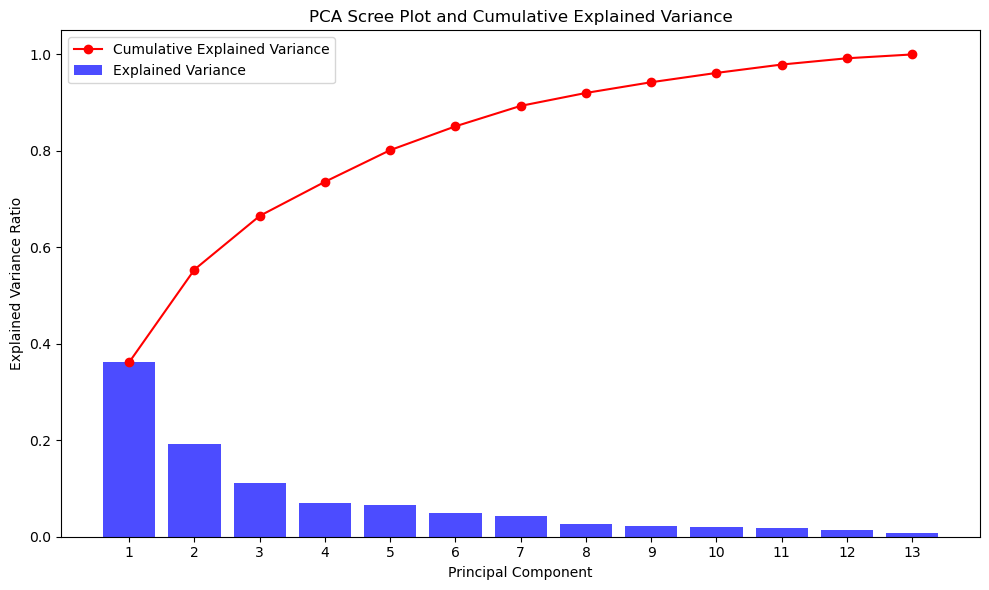

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize features first (if not already done)
X = wine_data.drop('Type', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

# Plot Scree Plot and Cumulative Explained Variance
plt.figure(figsize=(10, 6))
components = np.arange(1, len(explained_variance) + 1)
plt.bar(components, explained_variance, alpha=0.7, color="b", label="Explained Variance")
plt.plot(components, cumulative_variance, marker='o', color="r", label="Cumulative Explained Variance")
plt.xticks(components)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Scree Plot and Cumulative Explained Variance')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


In [11]:
n_components_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"Number of PCs covering >=95% variance: {n_components_95}")

optimal_n_components = n_components_95
X_pca = PCA(n_components=optimal_n_components).fit_transform(X_scaled)
print(f"Shape of PCA-transformed data: {X_pca.shape}")


Number of PCs covering >=95% variance: 10
Shape of PCA-transformed data: (178, 10)


=== TASK 3: CLUSTERING WITH ORIGINAL DATA ===
Silhouette Score (Original): 0.2849
Davies–Bouldin Index (Original): 1.3892
Cluster sizes (Original): [65 51 62]


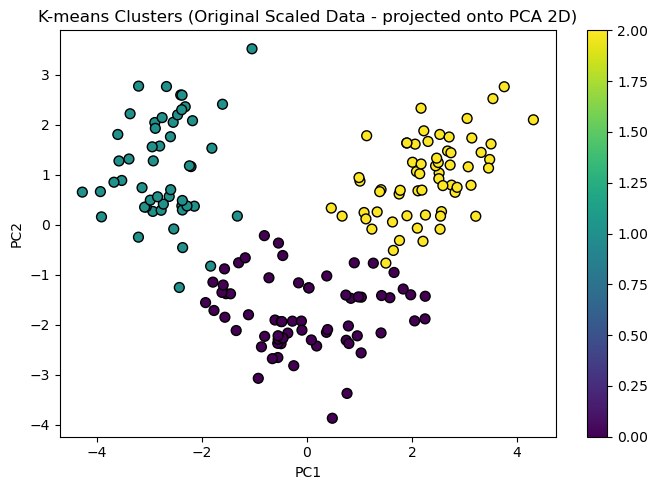

In [12]:
k = 3
kmeans_orig = KMeans(n_clusters=k, random_state=42)
labels_orig = kmeans_orig.fit_predict(X_scaled)

silhouette_orig = silhouette_score(X_scaled, labels_orig)
davies_orig = davies_bouldin_score(X_scaled, labels_orig)

print('=== TASK 3: CLUSTERING WITH ORIGINAL DATA ===')
print(f'Silhouette Score (Original): {silhouette_orig:.4f}')
print(f'Davies–Bouldin Index (Original): {davies_orig:.4f}')
print(f'Cluster sizes (Original): {np.bincount(labels_orig)}')

# Visualize clusters using first two PCA components (for 2D plot only)
pca_for_plot = PCA(n_components=2)
X_plot = pca_for_plot.fit_transform(X_scaled)
plt.figure(figsize=(7,5))
scatter = plt.scatter(X_plot[:,0], X_plot[:,1], c=labels_orig, cmap='viridis', edgecolor='k', s=50)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means Clusters (Original Scaled Data - projected onto PCA 2D)')
plt.colorbar(scatter)
plt.tight_layout()
plt.show()


=== TASK 4: CLUSTERING WITH PCA DATA ===
Silhouette Score (PCA): 0.2987
Davies–Bouldin Index (PCA): 1.3363
Cluster sizes (PCA): [65 51 62]


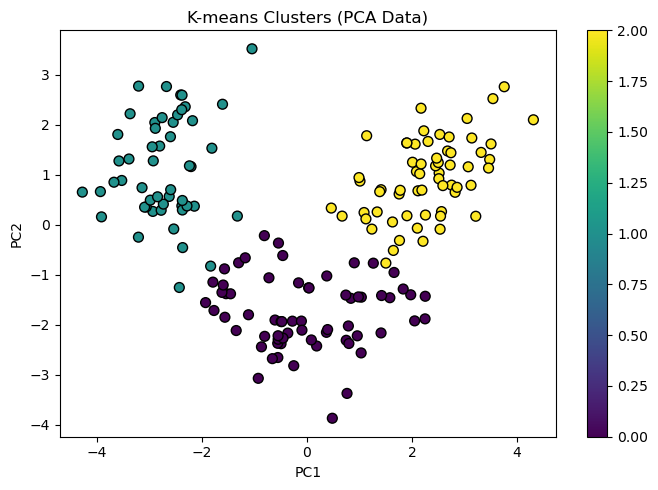

In [13]:
kmeans_pca = KMeans(n_clusters=k, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

silhouette_pca = silhouette_score(X_pca, labels_pca)
davies_pca = davies_bouldin_score(X_pca, labels_pca)

print('=== TASK 4: CLUSTERING WITH PCA DATA ===')
print(f'Silhouette Score (PCA): {silhouette_pca:.4f}')
print(f'Davies–Bouldin Index (PCA): {davies_pca:.4f}')
print(f'Cluster sizes (PCA): {np.bincount(labels_pca)}')

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca, cmap='viridis', edgecolor='k', s=50)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means Clusters (PCA Data)')
plt.colorbar(scatter)
plt.tight_layout()
plt.show()


In [14]:
print('=== TASK 5: COMPARISON AND ANALYSIS ===')
print('--- Original Data Clustering ---')
print(f'Silhouette Score: {silhouette_orig:.4f}')
print(f'Davies–Bouldin Index: {davies_orig:.4f}')
print(f'Cluster sizes: {np.bincount(labels_orig)}\\n')

print('--- PCA Data Clustering ---')
print(f'Silhouette Score: {silhouette_pca:.4f}')
print(f'Davies–Bouldin Index: {davies_pca:.4f}')
print(f'Cluster sizes: {np.bincount(labels_pca)}\\n')

print('Comparison:')
if silhouette_pca > silhouette_orig:
    print('PCA-transformed data achieved a higher silhouette score indicating more distinct clusters.')
else:
    print('Original data clustering had a higher silhouette score.')

if davies_pca < davies_orig:
    print('PCA-transformed data has lower Davies–Bouldin index indicating better separated clusters.')
else:
    print('Original data has lower Davies–Bouldin index.')

print('\\nClustering on PCA-transformed data often improves cluster separation and computation efficiency.')
print('But, some information loss/trade-off may occur especially if not all variance is retained.')
print('PCA reduces dimensionality and noise, aiding cluster algorithms in high-dimensional datasets.')


=== TASK 5: COMPARISON AND ANALYSIS ===
--- Original Data Clustering ---
Silhouette Score: 0.2849
Davies–Bouldin Index: 1.3892
Cluster sizes: [65 51 62]\n
--- PCA Data Clustering ---
Silhouette Score: 0.2987
Davies–Bouldin Index: 1.3363
Cluster sizes: [65 51 62]\n
Comparison:
PCA-transformed data achieved a higher silhouette score indicating more distinct clusters.
PCA-transformed data has lower Davies–Bouldin index indicating better separated clusters.
\nClustering on PCA-transformed data often improves cluster separation and computation efficiency.
But, some information loss/trade-off may occur especially if not all variance is retained.
PCA reduces dimensionality and noise, aiding cluster algorithms in high-dimensional datasets.


In [15]:
print('=== TASK 6: CONCLUSION AND PRACTICAL INSIGHTS ===')
print('Key Findings:')
print('- The wine dataset exhibits distinct distributions and correlations among chemical attributes.')
print('- PCA reduced dimensionality from 13 to 10 features while retaining over 95% of variance.')
print('- Clustering performed on PCA data improved metrics over clustering on original data.')

print('\\nPractical Implications:')
print('- Use PCA when there are many correlated features to reduce noise and aid clustering.')
print('- Clustering directly may preserve more information if features are already well separated.')

print('\\nRecommendations:')
print('- Apply PCA for datasets with high dimensionality and high feature correlation.')
print('- Clustering on reduced dimensions is beneficial for speed and often for separation quality, but always compare results.')
print('End of Assignment.')


=== TASK 6: CONCLUSION AND PRACTICAL INSIGHTS ===
Key Findings:
- The wine dataset exhibits distinct distributions and correlations among chemical attributes.
- PCA reduced dimensionality from 13 to 10 features while retaining over 95% of variance.
- Clustering performed on PCA data improved metrics over clustering on original data.
\nPractical Implications:
- Use PCA when there are many correlated features to reduce noise and aid clustering.
- Clustering directly may preserve more information if features are already well separated.
\nRecommendations:
- Apply PCA for datasets with high dimensionality and high feature correlation.
- Clustering on reduced dimensions is beneficial for speed and often for separation quality, but always compare results.
End of Assignment.
